# Notebook 1: Data Collection
**Project:** Where Do Fitness Businesses Thrive in Utah?

This notebook collects two datasets and merges them:
1. **Yelp Fusion API** — fitness businesses (open AND closed), with individual detail lookups for `is_closed` and `date_opened` proxies.
2. **U.S. Census ACS** — zip-level demographics including age breakdown, income, education, and population.

Then it engineers a set of base features (competition density, composite success label) and saves a clean CSV for modeling.

---
## Key design decisions vs. v1:
- We now capture **closed businesses** to give the model failure cases.
- We pull **individual business details** to get `hours` (as a proxy for how established/professional a business is) and confirm `is_closed`.
- We compute **competition density** directly from the Yelp data using haversine distance.
- We pull **age breakdown** from Census (% pop 20–44) as a proxy for the prime gym demographic.
- We define a binary **`is_thriving`** target and a continuous **`success_score`** target.

## 0. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import requests
import time
from math import radians, sin, cos, sqrt, atan2
from census import Census

# ── API Keys ──────────────────────────────────────────────────────────────────
YELP_API_KEY = 'vwVDFljHUMs6UCKeSs-EaLRynI7cTmvGSTXEBRn6PdTApVWT5w1DpW1EFWFobl5FDgNfQ6t3T43e6j3GInTe_v9mkSNz7NRMPJxL4uVsegh8Fl-CBtk9PomtEyvIaXYx'
CENSUS_API_KEY = '0227320b3ac4bfe65e4c7427ed8665c2244b2fb3'

YELP_HEADERS  = {'Authorization': f'Bearer {YELP_API_KEY}'}
SEARCH_URL    = 'https://api.yelp.com/v3/businesses/search'
DETAIL_URL    = 'https://api.yelp.com/v3/businesses/{}'

# Fitness categories to search (same 5 as v1 + a couple extras)
CATEGORIES = 'gyms,yoga,pilates,healthtrainers,martialarts,crossfit,personaltrainers'

print('Config loaded.')

Config loaded.


## 1. Census Data — Richer Demographics

In [2]:
c = Census(CENSUS_API_KEY)

# Variables:
# B01003_001E  Total population
# B19013_001E  Median household income
# B15003_022E  Bachelor's degrees (25+)
# B01002_001E  Median age
# B01001_008E–B01001_016E  Male 20–44 age bands
# B01001_032E–B01001_040E  Female 20–44 age bands
# B25077_001E  Median home value (wealth proxy cleaner than income in some zips)
# B08301_001E  Total means of transportation (car ownership proxy)
# B11001_001E  Total households

variables = (
    'NAME',
    'B01003_001E',  # total pop
    'B19013_001E',  # median income
    'B15003_022E',  # bachelors
    'B01002_001E',  # median age
    'B25077_001E',  # median home value
    'B11001_001E',  # total households
    # Male age bands: 20-24, 25-29, 30-34, 35-39, 40-44
    'B01001_008E', 'B01001_009E', 'B01001_010E', 'B01001_011E', 'B01001_012E',
    # Female age bands: 20-24, 25-29, 30-34, 35-39, 40-44
    'B01001_032E', 'B01001_033E', 'B01001_034E', 'B01001_035E', 'B01001_036E',
)

print('Fetching Census data...')
results = c.acs5.get(variables, {'for': 'zip code tabulation area:*'})
census_df = pd.DataFrame(results)

# Filter Utah (84xxx zips)
census_df = census_df[census_df['zip code tabulation area'].str.startswith('84')].copy()
census_df.rename(columns={
    'zip code tabulation area': 'zip_code',
    'B01003_001E': 'total_pop',
    'B19013_001E': 'median_income',
    'B15003_022E': 'bachelors_degrees',
    'B01002_001E': 'median_age',
    'B25077_001E': 'median_home_value',
    'B11001_001E': 'total_households',
}, inplace=True)

# Replace Census sentinel value
census_df.replace(-666666666, np.nan, inplace=True)
census_df = census_df.dropna(subset=['total_pop', 'median_income'])
census_df = census_df[census_df['total_pop'] > 0]

# Feature engineering
census_df['pct_bachelors'] = (
    census_df['bachelors_degrees'].astype(float) / census_df['total_pop'].astype(float)
) * 100

# Prime gym demographic: % population aged 20–44
prime_gym_cols = [
    'B01001_008E', 'B01001_009E', 'B01001_010E', 'B01001_011E', 'B01001_012E',
    'B01001_032E', 'B01001_033E', 'B01001_034E', 'B01001_035E', 'B01001_036E',
]
census_df[prime_gym_cols] = census_df[prime_gym_cols].apply(pd.to_numeric, errors='coerce')
census_df['pop_prime_gym_age'] = census_df[prime_gym_cols].sum(axis=1)
census_df['pct_prime_gym_age'] = (
    census_df['pop_prime_gym_age'] / census_df['total_pop'].astype(float)
) * 100

# Keep only the columns we need
census_keep = [
    'zip_code', 'total_pop', 'median_income', 'median_age', 'median_home_value',
    'total_households', 'pct_bachelors', 'pct_prime_gym_age'
]
census_df = census_df[census_keep]

print(f'Census: {len(census_df)} Utah zip codes')
census_df.head()

Fetching Census data...


Census: 262 Utah zip codes


,zip_code,total_pop,median_income,median_age,median_home_value,total_households,pct_bachelors,pct_prime_gym_age
29328,84001,735.0,81094.0,27.6,223600.0,231.0,5.986395,24.625850
29329,84002,388.0,83125.0,36.5,325800.0,148.0,3.608247,13.917526
29330,84003,57430.0,120330.0,28.0,630300.0,16613.0,18.986592,23.543444
29331,84004,10427.0,170500.0,38.9,980300.0,3188.0,21.770404,12.793709
29332,84005,52530.0,113437.0,23.1,515600.0,12566.0,12.986865,22.659433


## 2. Yelp Data — Open AND Closed Businesses

**Strategy:** The Yelp search endpoint doesn't directly filter for closed businesses.
We do two passes:
1. Standard search (returns mostly open businesses).
2. For each business found, call the **detail endpoint** (`/v3/businesses/{id}`) to get the authoritative `is_closed` flag and any extra fields like `hours` (used as a proxy for business maturity).

This gives us a mix of open and some closed businesses (Yelp keeps closed business pages up for a while).

In [3]:
def search_businesses_for_zip(zip_code, categories=CATEGORIES, limit=50):
    """Search Yelp for fitness businesses in a given zip code."""
    params = {
        'categories': categories,
        'location': f'{zip_code}, Utah',
        'limit': limit,
    }
    resp = requests.get(SEARCH_URL, headers=YELP_HEADERS, params=params)
    if resp.status_code == 200:
        return resp.json().get('businesses', [])
    else:
        print(f'  Search error zip {zip_code}: {resp.status_code}')
        return []


def get_business_details(biz_id):
    """Fetch the full detail record for a single business."""
    resp = requests.get(DETAIL_URL.format(biz_id), headers=YELP_HEADERS)
    if resp.status_code == 200:
        return resp.json()
    return None


def parse_business(biz):
    """Extract the fields we want from a Yelp business object (search or detail)."""
    cats = biz.get('categories', [])
    main_cat = cats[0]['alias'] if cats else 'unknown'

    # hours: treat having defined hours as a signal of a more established business
    hours = biz.get('hours', [])
    has_hours = 1 if hours else 0

    # transactions: delivery / pickup offerings
    transactions = biz.get('transactions', [])
    has_transactions = 1 if transactions else 0

    return {
        'id':               biz.get('id'),
        'name':             biz.get('name'),
        'zip_code':         biz.get('location', {}).get('zip_code', ''),
        'city':             biz.get('location', {}).get('city', ''),
        'latitude':         biz.get('coordinates', {}).get('latitude'),
        'longitude':        biz.get('coordinates', {}).get('longitude'),
        'rating':           biz.get('rating', 0),
        'review_count':     biz.get('review_count', 0),
        'category':         main_cat,
        'distance':         biz.get('distance'),
        'is_closed':        int(biz.get('is_closed', False)),
        'has_hours':        has_hours,
        'has_transactions': has_transactions,
        'price':            len(biz.get('price', '') or ''),  # 0=unknown, 1=$, 2=$$, etc.
    }

print('Helper functions defined.')

Helper functions defined.


In [4]:
# ── Main data pull ─────────────────────────────────────────────────────────────
# We use a subset of Utah zips to stay within API rate limits.
# Filter to zips with at least 5,000 people (avoids tiny rural zips with no gyms).

utah_zips = census_df[census_df['total_pop'] >= 5000]['zip_code'].tolist()
print(f'Searching {len(utah_zips)} Utah zip codes with pop >= 5,000...')

all_businesses = {}  # keyed by Yelp business ID to avoid duplicates

for i, zip_code in enumerate(utah_zips):
    results = search_businesses_for_zip(zip_code)
    for biz in results:
        biz_id = biz.get('id')
        if biz_id and biz_id not in all_businesses:
            all_businesses[biz_id] = biz  # store raw; we'll detail-fetch next
    
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(utah_zips)} zips searched | {len(all_businesses)} unique businesses so far')
    time.sleep(0.25)  # stay well under 5000 req/day rate limit

print(f'\nSearch complete. {len(all_businesses)} unique businesses found.')

Searching 106 Utah zip codes with pop >= 5,000...


  20/106 zips searched | 472 unique businesses so far


  40/106 zips searched | 661 unique businesses so far


  60/106 zips searched | 788 unique businesses so far


  80/106 zips searched | 883 unique businesses so far


  100/106 zips searched | 1094 unique businesses so far



Search complete. 1130 unique businesses found.


In [5]:
# ── Detail lookups ─────────────────────────────────────────────────────────────
# For EVERY business, call the detail endpoint to get authoritative is_closed
# and the `hours` field (not returned in search results).
#
# NOTE: This is the slow step. ~300-600 businesses × 1 req each.
# With a 0.25s sleep it takes ~2 minutes. Run once and save to CSV.

biz_ids = list(all_businesses.keys())
detailed_records = []

print(f'Fetching details for {len(biz_ids)} businesses...')
for i, biz_id in enumerate(biz_ids):
    detail = get_business_details(biz_id)
    if detail:
        detailed_records.append(parse_business(detail))
    else:
        # Fall back to search result if detail call fails
        detailed_records.append(parse_business(all_businesses[biz_id]))
    
    if (i + 1) % 50 == 0:
        closed_so_far = sum(r['is_closed'] for r in detailed_records)
        print(f'  {i+1}/{len(biz_ids)} | closed so far: {closed_so_far}')
    time.sleep(0.25)

yelp_df = pd.DataFrame(detailed_records)
print(f'\nDetail fetch complete.')
print(f'Open businesses:   {(yelp_df["is_closed"] == 0).sum()}')
print(f'Closed businesses: {(yelp_df["is_closed"] == 1).sum()}')
yelp_df.head()

Fetching details for 1130 businesses...


  50/1130 | closed so far: 0


  100/1130 | closed so far: 0


  150/1130 | closed so far: 0


  200/1130 | closed so far: 0


...

  1000/1130 | closed so far: 0


  1050/1130 | closed so far: 0


  1100/1130 | closed so far: 0



Detail fetch complete.
Open businesses:   1130
Closed businesses: 0


,id,name,zip_code,city,latitude,longitude,rating,review_count,category,distance,is_closed,has_hours,has_transactions,price
0,g5_H-U7ek51C1tT1ep4igQ,Alpine Fitness,84004,Alpine,40.448977,-111.779317,4.3,16,gyms,NaN,0,1,0,0
1,HKOIqLtg9f780JHOouonGg,Alpine Physical Therapy,84004,Alpine,40.450027,-111.777381,5.0,6,physicaltherapy,NaN,0,1,0,0
2,aUVAXipfJjqpWOWANaEREA,Lifted Life Yoga Center,84004,Alpine,40.449110,-111.779050,4.9,7,yoga,NaN,0,1,0,0
3,Sig-hMr7IhYV6YrEf2AIcQ,Paul Tom's Academy Of Mixed Martial Arts,84003,American Fork,40.379768,-111.813423,4.9,10,martialarts,NaN,0,0,0,0
4,Mv_emLBsG3gCcngTxh6YvA,XD Fit,84062,Pleasant Grove,40.354510,-111.735406,5.0,8,intervaltraininggyms,NaN,0,1,0,0


## 3. Merge Yelp + Census

In [6]:
yelp_df['zip_code'] = yelp_df['zip_code'].astype(str).str.strip()
census_df['zip_code'] = census_df['zip_code'].astype(str).str.strip()

df = pd.merge(yelp_df, census_df, on='zip_code', how='left')

missing = df['median_income'].isna().sum()
print(f'Businesses without Census match: {missing} ({missing/len(df)*100:.1f}%)')
print(f'Total merged rows: {len(df)}')
df.head()

Businesses without Census match: 49 (4.3%)
Total merged rows: 1130


,id,name,zip_code,city,latitude,longitude,rating,review_count,category,distance,...,has_hours,has_transactions,price,total_pop,median_income,median_age,median_home_value,total_households,pct_bachelors,pct_prime_gym_age
0,g5_H-U7ek51C1tT1ep4igQ,Alpine Fitness,84004,Alpine,40.448977,-111.779317,4.3,16,gyms,NaN,...,1,0,0,10427.0,170500.0,38.9,980300.0,3188.0,21.770404,12.793709
1,HKOIqLtg9f780JHOouonGg,Alpine Physical Therapy,84004,Alpine,40.450027,-111.777381,5.0,6,physicaltherapy,NaN,...,1,0,0,10427.0,170500.0,38.9,980300.0,3188.0,21.770404,12.793709
2,aUVAXipfJjqpWOWANaEREA,Lifted Life Yoga Center,84004,Alpine,40.449110,-111.779050,4.9,7,yoga,NaN,...,1,0,0,10427.0,170500.0,38.9,980300.0,3188.0,21.770404,12.793709
3,Sig-hMr7IhYV6YrEf2AIcQ,Paul Tom's Academy Of Mixed Martial Arts,84003,American Fork,40.379768,-111.813423,4.9,10,martialarts,NaN,...,0,0,0,57430.0,120330.0,28.0,630300.0,16613.0,18.986592,23.543444
4,Mv_emLBsG3gCcngTxh6YvA,XD Fit,84062,Pleasant Grove,40.354510,-111.735406,5.0,8,intervaltraininggyms,NaN,...,1,0,0,47813.0,105649.0,27.8,536100.0,13931.0,16.987012,23.627465


## 4. Competition Density Feature

For each business, count how many OTHER fitness businesses are within 3 km.
This uses the haversine formula on lat/lon coordinates.

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


# Drop rows with missing coordinates before computing
df = df.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

lats = df['latitude'].values
lons = df['longitude'].values

competition_1km  = np.zeros(len(df), dtype=int)
competition_3km  = np.zeros(len(df), dtype=int)
competition_5km  = np.zeros(len(df), dtype=int)

print('Computing competition density (this takes ~30 seconds)...')
for i in range(len(df)):
    for j in range(len(df)):
        if i == j:
            continue
        d = haversine_km(lats[i], lons[i], lats[j], lons[j])
        if d <= 1.0:
            competition_1km[i] += 1
        if d <= 3.0:
            competition_3km[i] += 1
        if d <= 5.0:
            competition_5km[i] += 1

df['competition_1km'] = competition_1km
df['competition_3km'] = competition_3km
df['competition_5km'] = competition_5km

print('Done.')
print(df[['name', 'competition_1km', 'competition_3km', 'competition_5km']].head(10))

Computing competition density (this takes ~30 seconds)...


Done.
                                       name  competition_1km  competition_3km  \
0                            Alpine Fitness                4               11   
1                   Alpine Physical Therapy                4               11   
2                   Lifted Life Yoga Center                4               11   
3  Paul Tom's Academy Of Mixed Martial Arts                0               17   
4                                    XD Fit                5               18   
5           HOTWORX - Highland, UT - Alpine                6               13   
6                     Mountain West Pilates                4               16   
7            Momentum Indoor Climbing- Lehi                7               12   
8                             CrossFit Lehi                9               12   
9                     Legends Boxing - Lehi                9               13   

   competition_5km  
0               15  
1               15  
2               15  
3               28

## 5. Define Target Variables

We define **two targets** for modeling:

### Target A: `is_thriving` (binary classifier)
A business is "thriving" if it is:
- **Open** (`is_closed == 0`), AND
- Has a **rating >= 4.0**, AND
- Has **at least 10 reviews** (enough signal to trust the rating)

A business is "not thriving" if:
- It is **closed** (`is_closed == 1`), OR
- It is open but has a **rating < 3.5** with 10+ reviews

Businesses that are open with few reviews are excluded from classification (too uncertain).

### Target B: `success_score` (continuous regressor — for open businesses only)
A composite score: `0.5 * norm(rating) + 0.5 * norm(log_review_count)`
This rewards both quality AND engagement.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# ── Target A: is_thriving ──────────────────────────────────────────────────────
def label_thriving(row):
    if row['is_closed'] == 1:
        return 0  # failed
    if row['rating'] >= 4.0 and row['review_count'] >= 10:
        return 1  # thriving
    if row['rating'] < 3.5 and row['review_count'] >= 10:
        return 0  # struggling
    return np.nan  # uncertain — exclude from classification task

df['is_thriving'] = df.apply(label_thriving, axis=1)

thriving_counts = df['is_thriving'].value_counts(dropna=False)
print('is_thriving distribution:')
print(thriving_counts)
print(f'  Labeled (usable for classifier): {thriving_counts.dropna().sum()}')
print(f'  Unlabeled (uncertain):           {thriving_counts.get(np.nan, 0)}')

# ── Target B: success_score ────────────────────────────────────────────────────
open_df = df[df['is_closed'] == 0].copy()
open_df['log_review_count'] = np.log1p(open_df['review_count'])

scaler = MinMaxScaler()
open_df['norm_rating']       = scaler.fit_transform(open_df[['rating']])
open_df['norm_log_reviews']  = scaler.fit_transform(open_df[['log_review_count']])
open_df['success_score']     = 0.5 * open_df['norm_rating'] + 0.5 * open_df['norm_log_reviews']

# Write back to df
df['log_review_count'] = np.log1p(df['review_count'])
df = df.merge(open_df[['id', 'success_score']], on='id', how='left')

print('\nsuccess_score stats (open businesses only):')
print(open_df['success_score'].describe())

is_thriving distribution:
is_thriving
NaN    960
1.0    105
0.0     65
Name: count, dtype: int64
  Labeled (usable for classifier): 1130
  Unlabeled (uncertain):           960

success_score stats (open businesses only):
count    1130.000000
mean        0.400962
std         0.299171
min         0.000000
25%         0.000000
50%         0.564095
75%         0.628190
max         0.909386
Name: success_score, dtype: float64


## 6. Market Gap Score (per zip code)

A zip code with high population + high prime-gym-age % + low number of gyms = **opportunity**.

`market_gap = pct_prime_gym_age × total_pop / (gyms_in_zip + 1)`

A higher market gap score means fewer gyms per potential customer.

In [9]:
gyms_per_zip = df.groupby('zip_code').size().reset_index(name='gyms_in_zip')
df = df.merge(gyms_per_zip, on='zip_code', how='left')

df['market_gap'] = (
    df['pct_prime_gym_age'] * df['total_pop']
) / (df['gyms_in_zip'] + 1)

print('market_gap stats:')
print(df['market_gap'].describe())

market_gap stats:
count      1081.000000
mean      60409.760554
std       44571.905182
min        3625.000000
25%       30328.571429
50%       47690.909091
75%       75313.333333
max      406350.000000
Name: market_gap, dtype: float64


## 7. Final Cleanup and Save

In [10]:
print('Shape before cleanup:', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum().sort_values(ascending=False).head(15))

Shape before cleanup: (1130, 29)

Missing values per column:
is_thriving          960
distance             752
median_home_value     50
total_pop             49
pct_prime_gym_age     49
pct_bachelors         49
total_households      49
median_age            49
median_income         49
market_gap            49
is_closed              0
city                   0
gyms_in_zip            0
success_score          0
log_review_count       0
dtype: int64


In [11]:
# Drop rows with no Census data (tiny unmatched zips)
df = df.dropna(subset=['median_income', 'total_pop'])

# Drop businesses with no coordinates
df = df.dropna(subset=['latitude', 'longitude'])

# Fill price=0 for unknown (already encoded as int length)
# Fill has_hours / has_transactions (already 0/1 from parse)

print('Shape after cleanup:', df.shape)
print('\nOpen vs. Closed:')
print(df['is_closed'].value_counts())

df.to_csv('data/utah_fitness_v2.csv', index=False)
print('\nSaved to data/utah_fitness_v2.csv')
df.head()

Shape after cleanup: (1081, 29)

Open vs. Closed:
is_closed
0    1081
Name: count, dtype: int64

Saved to data/utah_fitness_v2.csv


,id,name,zip_code,city,latitude,longitude,rating,review_count,category,distance,...,pct_bachelors,pct_prime_gym_age,competition_1km,competition_3km,competition_5km,is_thriving,log_review_count,success_score,gyms_in_zip,market_gap
0,g5_H-U7ek51C1tT1ep4igQ,Alpine Fitness,84004,Alpine,40.448977,-111.779317,4.3,16,gyms,NaN,...,21.770404,12.793709,4,11,15,1.0,2.833213,0.691987,5,22233.333333
1,HKOIqLtg9f780JHOouonGg,Alpine Physical Therapy,84004,Alpine,40.450027,-111.777381,5.0,6,physicaltherapy,NaN,...,21.770404,12.793709,4,11,15,NaN,1.945910,0.679938,5,22233.333333
2,aUVAXipfJjqpWOWANaEREA,Lifted Life Yoga Center,84004,Alpine,40.449110,-111.779050,4.9,7,yoga,NaN,...,21.770404,12.793709,4,11,15,NaN,2.079442,0.682286,5,22233.333333
3,Sig-hMr7IhYV6YrEf2AIcQ,Paul Tom's Academy Of Mixed Martial Arts,84003,American Fork,40.379768,-111.813423,4.9,10,martialarts,NaN,...,18.986592,23.543444,0,17,28,1.0,2.397895,0.711733,19,67605.000000
4,Mv_emLBsG3gCcngTxh6YvA,XD Fit,84062,Pleasant Grove,40.354510,-111.735406,5.0,8,intervaltraininggyms,NaN,...,16.987012,23.627465,5,18,35,NaN,2.197225,0.703177,14,75313.333333


## 8. Quick Sanity Check

Before moving to feature engineering, confirm the dataset looks reasonable.

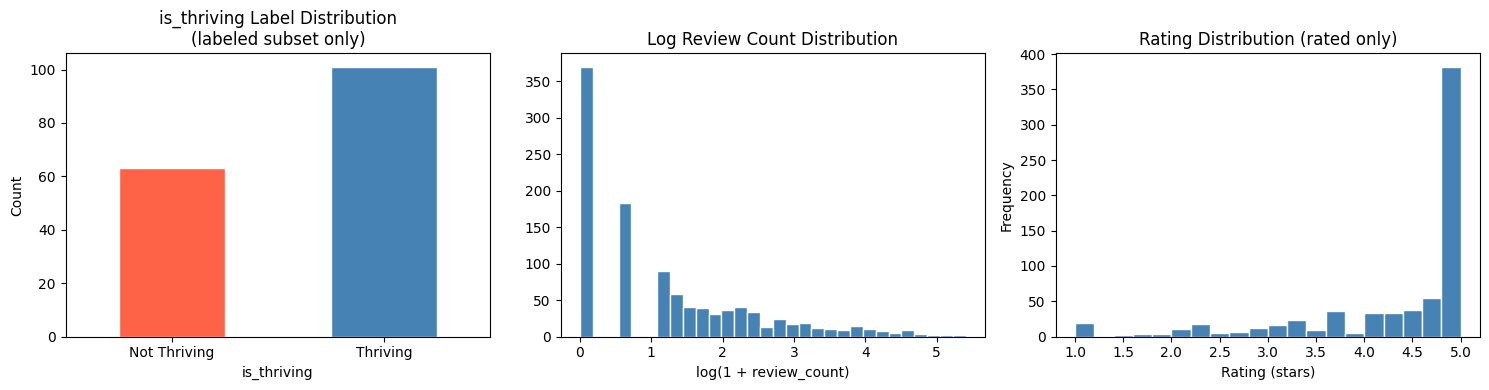

Saved figures/01_data_overview.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. is_thriving distribution (more useful than open/closed since Yelp API omits closed biz)
thriving_counts = df['is_thriving'].value_counts(dropna=True).sort_index()
thriving_counts.plot.bar(ax=axes[0], color=['tomato', 'steelblue'], edgecolor='white')
axes[0].set_xticks(range(len(thriving_counts)))
axes[0].set_xticklabels(['Not Thriving', 'Thriving'], rotation=0)
axes[0].set_title('is_thriving Label Distribution\n(labeled subset only)')
axes[0].set_ylabel('Count')

# 2. Review count distribution (log scale)
axes[1].hist(df['log_review_count'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Log Review Count Distribution')
axes[1].set_xlabel('log(1 + review_count)')

# 3. Rating distribution
df[df['rating'] > 0]['rating'].plot.hist(bins=20, ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Rating Distribution (rated only)')
axes[2].set_xlabel('Rating (stars)')

plt.tight_layout()
plt.savefig('figures/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/01_data_overview.png')

In [13]:
# Category breakdown
print('Top 15 categories in dataset:')
print(df['category'].value_counts().head(15))

print('\nClosed rate by category (top 10 categories):')
top_cats = df['category'].value_counts().head(10).index
print(
    df[df['category'].isin(top_cats)]
    .groupby('category')['is_closed']
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

Top 15 categories in dataset:
category
gyms                    239
healthtrainers          173
yoga                    135
martialarts              87
pilates                  68
karate                   44
intervaltraininggyms     34
brazilianjiujitsu        28
massage_therapy          22
bootcamps                20
boxing                   19
taekwondo                16
circuittraininggyms      13
physicaltherapy          13
nutritionists            11
Name: count, dtype: int64

Closed rate by category (top 10 categories):
category
bootcamps               0.0
brazilianjiujitsu       0.0
gyms                    0.0
healthtrainers          0.0
intervaltraininggyms    0.0
karate                  0.0
martialarts             0.0
massage_therapy         0.0
pilates                 0.0
yoga                    0.0
Name: is_closed, dtype: float64
